# Histopathology Metastasis Classification (PatchCamelyon)

Binary patch-level classifier (tumor vs. normal) trained on the PatchCamelyon (PCam) benchmark, using transfer learning from a ResNet18 backbone. Full write-up, results, and error analysis are in the project [README](./README.md); this notebook contains the code for the data pipeline, model training, evaluation, and Grad-CAM interpretability analysis described there.

**Note on data:** PCam is large (~6 GB) and is not included in this repo. Download it from the [official PCam repo](https://github.com/basveeling/pcam) or [Kaggle](https://www.kaggle.com/datasets/wdelaney/patchcamelyon), and update the file paths in the *Data loaders* cell below to point at your local copy.

## Exploratory Data Analysis

Before writing any model code: confirm the class balance across splits, and look at a handful of actual patches to sanity-check that images and labels line up as expected.

### Class balance across splits

In [1]:
import pandas as pd

# Load the CSV files
train_df = pd.read_csv("/kaggle/input/datasets/wdelaney/patchcamelyon/Metadata/Metadata/train_metadata.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/wdelaney/patchcamelyon/Metadata/Metadata/valid_metadata.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/wdelaney/patchcamelyon/Metadata/Metadata/test_metadata.csv")

# Add dataset labels
train_df["dataset"] = "Train"
val_df["dataset"] = "Validation"
test_df["dataset"] = "Test"

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# "tumor_patch" is a boolean column: True means the patch is labeled tumor.
# .sum() on it counts True values (tumor patches); (~x).sum() counts False
# values (normal patches) — keep the aggregation names matched to that.
tumor_counts = all_df.groupby("dataset")["tumor_patch"].agg(
    normal_patch=lambda x: (~x).sum(),
    tumor_patch="sum",
).reset_index()

display(tumor_counts)


,dataset,normal_patch,tumor_patch
0,Test,16294,16474
1,Train,130399,131745
2,Validation,16310,16458


### Sample patches

Sampled by class rather than by position in the file — the raw H5 files aren't guaranteed to be shuffled, so grabbing the first N patches risks a grid that's accidentally all one class.

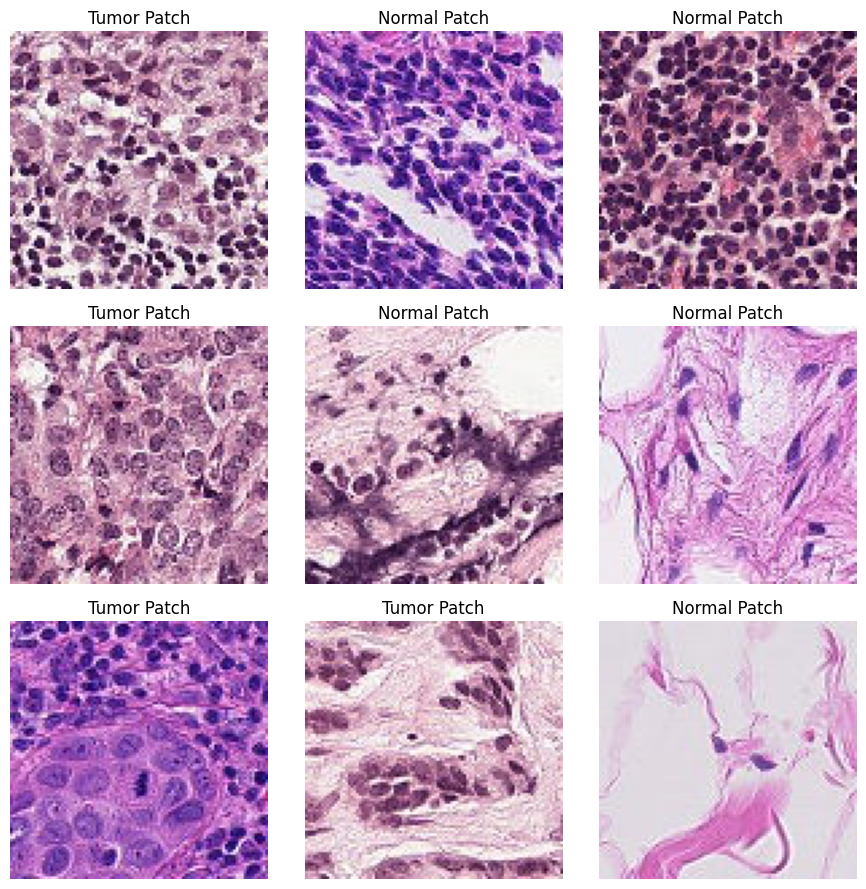

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

x_path = "/kaggle/input/datasets/wdelaney/patchcamelyon/pcam/training_split.h5"
y_path = "/kaggle/input/datasets/wdelaney/patchcamelyon/Labels/Labels/camelyonpatch_level_2_split_train_y.h5"

with h5py.File(x_path, "r") as x_file, h5py.File(y_path, "r") as y_file:
    images = x_file["x"]
    labels = y_file["y"][:].reshape(-1)  # (N, 1, 1, 1) -> (N,)

    rng = np.random.default_rng(0)
    normal_sample = rng.choice(np.where(labels == 0)[0], size=5, replace=False)
    tumor_sample = rng.choice(np.where(labels == 1)[0], size=5, replace=False)
    sample_indices = np.concatenate([normal_sample, tumor_sample])
    rng.shuffle(sample_indices)
    sample_indices = sample_indices[:9]

    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for ax, idx in zip(axes.flat, sample_indices):
        ax.imshow(images[idx])
        ax.axis("off")
        ax.set_title("Tumor Patch" if labels[idx] == 1 else "Normal Patch")

    plt.tight_layout()
    plt.show()


## Baseline: a small CNN trained from scratch

Used as a pipeline-correctness check and a performance floor, not as a serious model.

In [3]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: (batch, 3, 96, 96) - 3 color channels, 96x96 pixels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # two 2x2 max-pools halve the spatial size twice: 96 -> 48 -> 24
        self.fc1 = nn.Linear(in_features=64*24*24, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=2)  # 2 logits: "normal" vs "tumor"
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Dataset

A lazy-loading `Dataset` over the PCam HDF5 files — file handles are opened on first access rather than at construction, so this works cleanly with multiple `DataLoader` workers.

In [5]:
import torch
from torch.utils.data import Dataset
import h5py

class PCamDataset(Dataset):
    def __init__(self, x_path, y_path, transform=None):
        self.x_path = x_path
        self.y_path = y_path
        self.x_file = None
        self.y_file = None
        self.transform = transform

    def __len__(self):
        if self.x_file is None:
            self.x_file = h5py.File(self.x_path, "r")
        return self.x_file["x"].shape[0]

    def __getitem__(self, idx):
        if self.x_file is None:
            self.x_file = h5py.File(self.x_path, "r")
        if self.y_file is None:
            self.y_file = h5py.File(self.y_path, "r")

        image = self.x_file["x"][idx]
        label = int(self.y_file["y"][idx].squeeze())

        if self.transform:
            image = self.transform(image)  # note: applied to the RAW image,
                                             # before your manual transpose/normalize
        else:
            image = image.transpose(2, 0, 1).astype("float32") / 255.0
            image = torch.from_numpy(image)

        return image, label

## Data augmentation

Histology patches have no canonical orientation (unlike natural photos), and H&E staining varies across labs and scanners — so the model is trained to be invariant to flips/rotation and mild color variation.

In [6]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
])

## Data loaders

*Update the paths below to point at your local copy of the PCam `.h5` files.*

In [7]:
from torch.utils.data import DataLoader

train_dataset = PCamDataset("/kaggle/input/datasets/wdelaney/patchcamelyon/pcam/training_split.h5", "/kaggle/input/datasets/wdelaney/patchcamelyon/Labels/Labels/camelyonpatch_level_2_split_train_y.h5", transform=train_transform)
val_dataset = PCamDataset("/kaggle/input/datasets/wdelaney/patchcamelyon/pcam/validation_split.h5", "/kaggle/input/datasets/wdelaney/patchcamelyon/Labels/Labels/camelyonpatch_level_2_split_valid_y.h5", transform=None)
test_dataset = PCamDataset("/kaggle/input/datasets/wdelaney/patchcamelyon/pcam/test_split.h5", "/kaggle/input/datasets/wdelaney/patchcamelyon/Labels/Labels/camelyonpatch_level_2_split_test_y.h5", transform=None)


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)


## Evaluation utility

Both models get evaluated the same way, so this is written once as a function instead of copy-pasted per model. It reports balanced accuracy and macro F1 (informative even on a roughly-balanced dataset like PCam, and the standard choice if that ever changes), a full classification report, and a confusion matrix heatmap. It also returns the per-example tumor-probabilities — the ResNet run reuses those directly for the false-negative analysis below, instead of re-running inference a second time.

In [8]:
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, classification_report, confusion_matrix
)

CLASS_NAMES = ("normal", "tumor")

def evaluate_model(model, data_loader, device, class_names=CLASS_NAMES, title="Model"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())   # P(tumor)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    print(f"\n{title} — Evaluation")
    print("\nBalanced Accuracy")
    print(balanced_accuracy_score(all_labels, all_preds))
    print("\nMacro F1")
    print(f1_score(all_labels, all_preds, average="macro"))
    print("\nClassification Report")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, cmap="Blues", fmt="d",
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title} — Confusion Matrix")
    plt.show()

    return all_preds, all_labels, all_probs


## Train the baseline CNN

In [18]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
num_epochs = 4
best_val_accuracy = 0.0
best_epoch = None

for epoch in range(num_epochs):
    baseline_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    baseline_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = baseline_model(images)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_accuracy={val_accuracy:.4f}")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        torch.save(baseline_model.state_dict(), f"baseline_weights_epoch_{epoch+1}.pt")

print(f"Best epoch: {best_epoch} (val_accuracy={best_val_accuracy:.4f})")

Epoch 1: train_loss=0.4876, val_accuracy=0.8001
Epoch 2: train_loss=0.4289, val_accuracy=0.8123
Epoch 3: train_loss=0.3929, val_accuracy=0.8214
Epoch 4: train_loss=0.3677, val_accuracy=0.8275
Best epoch: 4 (val_accuracy=0.8275)


### Evaluate the baseline CNN

Reload the checkpoint from its best epoch (not just whatever is left in memory after the loop finishes) before evaluating.


Baseline CNN — Evaluation

Balanced Accuracy
0.8116136333684177

Macro F1
0.8105814151643409

Classification Report
              precision    recall  f1-score   support

      normal       0.77      0.89      0.82     16391
       tumor       0.87      0.74      0.80     16377

    accuracy                           0.81     32768
   macro avg       0.82      0.81      0.81     32768
weighted avg       0.82      0.81      0.81     32768



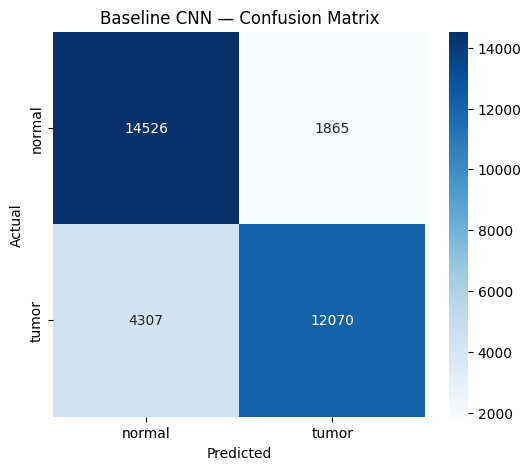

In [19]:
baseline_model.load_state_dict(torch.load(f"baseline_weights_epoch_{best_epoch}.pt"))
baseline_preds, baseline_labels, baseline_probs = evaluate_model(
    baseline_model, test_loader, device, title="Baseline CNN"
)


## Transfer learning: ResNet18

Freeze the early, generic-feature layers (`layer1`–`layer3`) and fine-tune only `layer4` plus a newly-initialized classification head — a middle ground between freezing the whole backbone and fully unfreezing it.

In [9]:
import torchvision.models as models

resnet_model = models.resnet18(weights="IMAGENET1K_V1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


In [10]:
# Step 1: freeze everything
for param in resnet_model.parameters():
    param.requires_grad = False

# Step 2: unfreeze layer4
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

# Step 3: replace the final layer (this new layer's params are
# requires_grad=True by default, since it's freshly created)
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 2)

resnet_model = resnet_model.to(device)


## Fine-tune with discriminative learning rates

A single shared learning rate under-trains the freshly-initialized head, so `layer4` and the new `fc` layer are trained at different rates.

In [11]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([{"params": resnet_model.layer4.parameters(), "lr": 0.0001},{"params": resnet_model.fc.parameters(), "lr": 0.001}], weight_decay=1e-4)
num_epochs = 4
best_val_accuracy = 0.0
best_epoch = None

for epoch in range(num_epochs):
    resnet_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    resnet_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = resnet_model(images)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_accuracy={val_accuracy:.4f}")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        torch.save(resnet_model.state_dict(), f"resnet_weights_epoch_{epoch+1}.pt")

print(f"Best epoch: {best_epoch} (val_accuracy={best_val_accuracy:.4f})")

Epoch 1: train_loss=0.3041, val_accuracy=0.8526
Epoch 2: train_loss=0.2498, val_accuracy=0.8609
Epoch 3: train_loss=0.2276, val_accuracy=0.8553
Epoch 4: train_loss=0.2150, val_accuracy=0.8586
Best epoch: 2 (val_accuracy=0.8609)


### Evaluate the fine-tuned ResNet18

Same function, same metrics — directly comparable to the baseline above. Reload the best checkpoint first.


ResNet18 (Transfer Learning) — Evaluation

Balanced Accuracy
0.8231960771106472

Macro F1
0.8211453362563411

Classification Report
              precision    recall  f1-score   support

      normal       0.77      0.93      0.84     16391
       tumor       0.91      0.72      0.80     16377

    accuracy                           0.82     32768
   macro avg       0.84      0.82      0.82     32768
weighted avg       0.84      0.82      0.82     32768



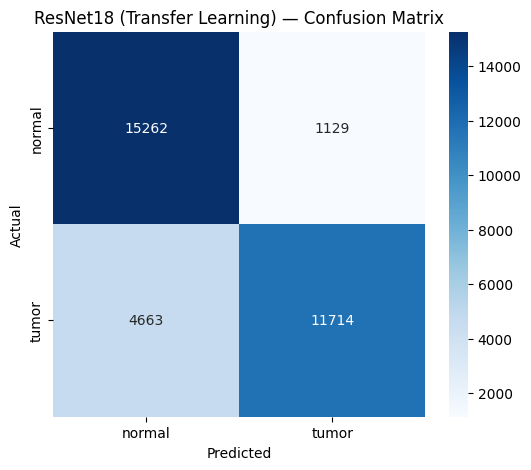

In [13]:
resnet_model.load_state_dict(torch.load(f"resnet_weights_epoch_{best_epoch}.pt"))
resnet_preds, resnet_labels, resnet_probs = evaluate_model(
    resnet_model, test_loader, device, title="ResNet18 (Transfer Learning)"
)


### Are false negatives borderline, or confidently wrong?

Looking at the model's predicted tumor-probability specifically on false negatives (real tumor patches predicted as normal).

In [14]:
mask = (resnet_preds == 0) & (resnet_labels == 1)
selected_probabilities = resnet_probs[mask]

selected_probabilities = np.array(selected_probabilities)
print("Mean:", selected_probabilities.mean())
print("Median:", np.median(selected_probabilities))
print("Max:", selected_probabilities.max())
print("% above 0.4:", (selected_probabilities > 0.4).mean())

Mean: 0.22108465
Median: 0.2062462
Max: 0.4989772
% above 0.4: 0.15183358352991635


## Interpretability: Grad-CAM on false negatives

PCam labels depend only on whether tumor tissue touches the center 32×32 region of the 96×96 patch. Grad-CAM on `layer4` shows where the model's tumor-class attention concentrates, to check whether false negatives are driven by attention landing outside that labeled region.

In [16]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=30ae22a359e5153e48a5e6422aa178bbf756003bcd809ce88a9ffb407e27ddb2
  Stored in directory: /root/.cache/pip/wheels/05/bd/e2/0c0eecf3c26b6cdb231b5656d53905bddc8090d69619d57e6b
Successfully built grad-cam


In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = resnet_model.layer4
cam = GradCAM(model=resnet_model, target_layers=target_layers)


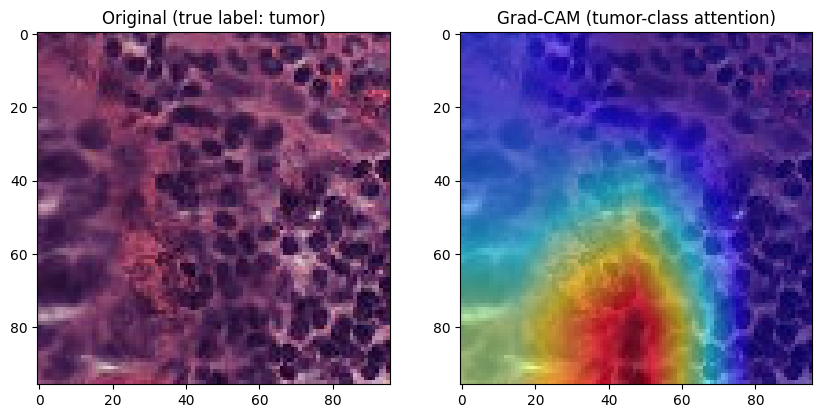

In [18]:
fn_mask = (resnet_preds == 0) & (resnet_labels == 1)
fn_indices = np.where(fn_mask)[0]
fn_probs = resnet_probs[fn_mask]

sorted_order = np.argsort(fn_probs)
idx = fn_indices[sorted_order[len(sorted_order) // 2]]  # median-confidence false negative

image_tensor, true_label = test_dataset[idx]
input_tensor = image_tensor.unsqueeze(0).to(device)

targets = [ClassifierOutputTarget(1)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

rgb_image = image_tensor.permute(1, 2, 0).numpy()
visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb_image)
axes[0].set_title(f"Original (true label: {'tumor' if true_label==1 else 'normal'})")
axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM (tumor-class attention)")
plt.show()

## Results

See the [README](./README.md) for the full results table, the augmentation experiment that resolved the recall problem, and discussion of remaining limitations.